In [33]:
import pandas as pd
import numpy as np

In [34]:
event_logs = pd.read_csv('../filtered_datasets/event_logs(1).csv')
marketing_summary = pd.read_csv('../filtered_datasets/marketing_summary(1).csv')
trend_report = pd.read_csv('../filtered_datasets/trend_report(1).csv')


# 1. Customer Types

In [35]:
event_logs.head()

,user_id,event_type,event_time,product_id,amount
0,U0099,checkout,2023-06-03 04:13:00,P010,NaN
1,U0240,wishlist_add,2023-06-03 05:08:00,P020,0.0
2,U0374,profile_update,2023-06-05 06:22:00,P028,0.0
3,U0122,page_view,2023-06-06 03:45:00,P001,0.0
4,U0211,wishlist_add,2023-06-03 12:38:00,P015,0.0


In [36]:
purchase_counts = (
    event_logs[event_logs['event_type'] == 'checkout']
    .groupby('user_id')
    .size()
    .reset_index(name='purchase_count')
)

In [37]:
user_segments = (
    event_logs[['user_id']]
    .drop_duplicates()
    .merge(purchase_counts, on='user_id', how='left')
)

In [38]:
#replace missing purchases with 0
user_segments['purchase_count'] = (
    user_segments['purchase_count']
    .fillna(0)
    .astype(int)
)

In [39]:
#create segments
user_segments['segment'] = user_segments['purchase_count'].apply(
    lambda x:
        'Non Buyer' if x == 0 else
        'Single Buyer' if x == 1 else
        'Repeat Buyer'
)

In [40]:
user_segments.to_csv('user_segments.csv', index = False)

# 2. Trend Report Forecast

In [41]:
#create time grain
event_logs['event_time'] = pd.to_datetime(event_logs['event_time'])

event_logs['event_hour'] = event_logs['event_time'].dt.floor('H')

event_logs['date'] = event_logs['event_time'].dt.date
# aggregate events by hour
events_per_hour = (
    event_logs
    .groupby('event_hour')
    .size()
    .reset_index(name='total_events')
)

#aggregate users per hour
users_per_hour = (
    event_logs
    .groupby('event_hour')['user_id']
    .nunique()
    .reset_index(name='unique_users')
)

#merge
hourly_engagement = events_per_hour.merge(
    users_per_hour,
    on='event_hour',
    how='outer'
).sort_values('event_hour')

/var/folders/fb/r3xfzh555slbpdxcyfkj672w0000gn/T/ipykernel_9235/2677165361.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  event_logs['event_hour'] = event_logs['event_time'].dt.floor('H')


In [42]:
hourly_engagement.head()

,event_hour,total_events,unique_users
0,2023-06-01 08:00:00,16,16
1,2023-06-01 09:00:00,10,10
2,2023-06-01 10:00:00,5,5
3,2023-06-01 11:00:00,17,17
4,2023-06-01 12:00:00,17,17


<Axes: >

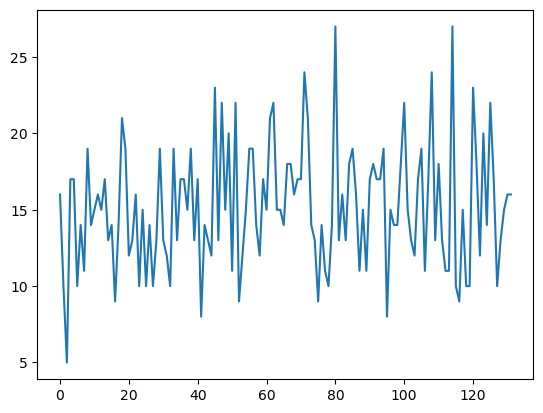

In [44]:
hourly_engagement['total_events'].plot()

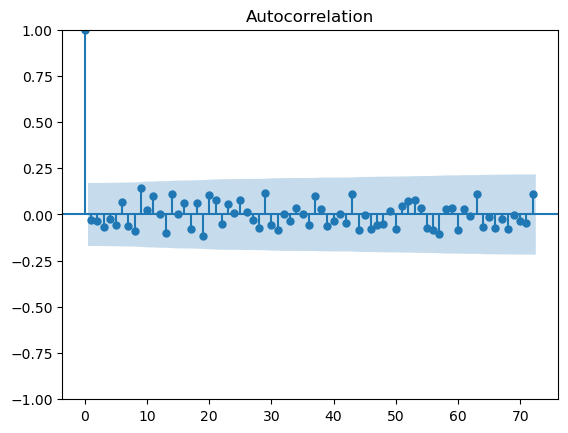

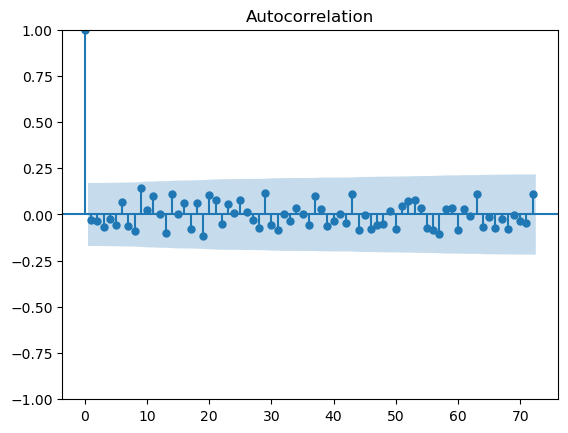

In [47]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(hourly_engagement['total_events'].dropna(), lags=72)

In [49]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(hourly_engagement['total_events'].dropna())
print(result[1])

1.7693632349223496e-21


<Axes: >

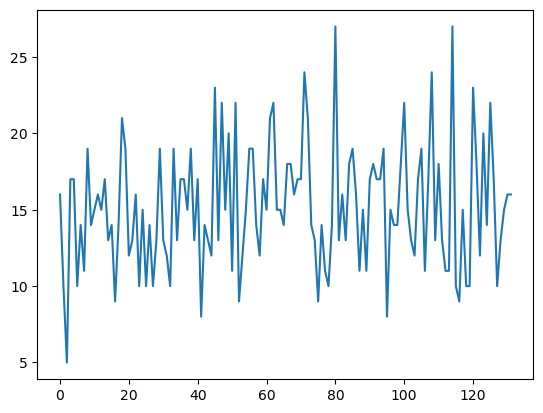

In [ ]:
#Plug in ARIMA

hourly = hourly_engagement.set_index('event_hour').sort_index()
#check time gaps
hourly = hourly.asfreq('H')
hourly['total_events'] = hourly['total_events'].fillna(0)
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(hourly['total_events'], order=(1,0,1))
result = model.fit()